<a href="https://colab.research.google.com/github/SilverShadow123/Python/blob/master/Clustering_%26_Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# **K-Means Clustering & Elbow Method**

**Load the Iris dataset.**

In [ ]:
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

features_names = iris.feature_names

df = pd.DataFrame(X, columns=features_names)
df['target'] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
display(df.info())
display(df.describe())
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


None

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Use the Elbow Method to determine the optimal number of clusters.**

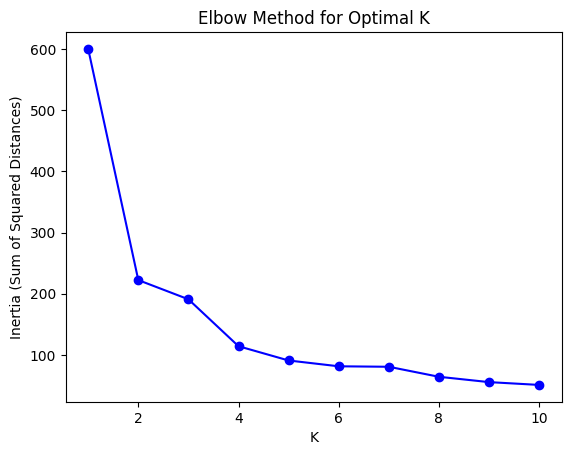

In [ ]:
inertia = []
K = range(1, 11)

for k in K:
  km = KMeans(n_clusters=k, random_state = 42)
  km.fit(X_scaled)
  inertia.append(km.inertia_)
plt.plot(K, inertia, 'bo-')
plt.xlabel('K')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal K')
plt.show()

**Apply K-Means clustering.**

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = clusters

**Plot clusters in 2D (first two features) or 3D (first three features).**

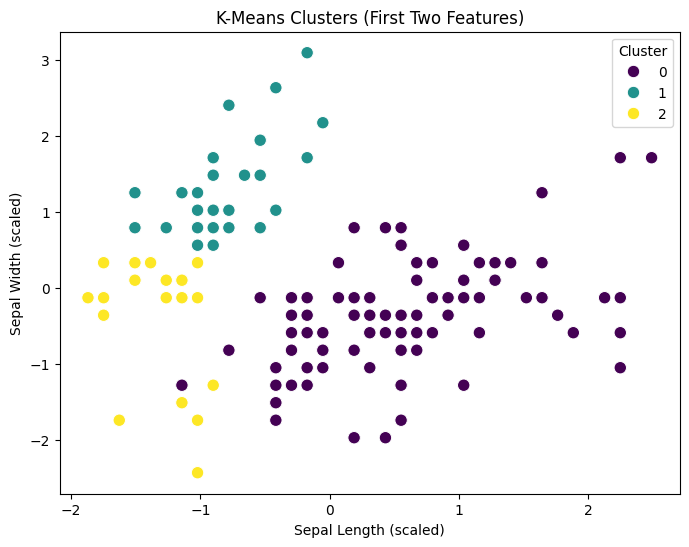

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=df['KMeans_Cluster'],
    palette='viridis',
    s=80
)

plt.xlabel("Sepal Length (scaled)")
plt.ylabel("Sepal Width (scaled)")
plt.title("K-Means Clusters (First Two Features)")
plt.legend(title="Cluster")
plt.show()

**Interpret clusters: cluster composition and separation.**

In [ ]:
display(pd.crosstab(df['KMeans_Cluster'], df['target']))

target,0,1,2
KMeans_Cluster,,,
0,0,46,50
1,33,0,0
2,17,4,0


**Interpretation of Clusters:**

Setosa forms a mostly separate cluster showing clear separation from the other species. Versicolor and Virginica overlap in the same cluster indicating partial separation due to similar feature values.

# **Principal Component Analysis (PCA)**

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

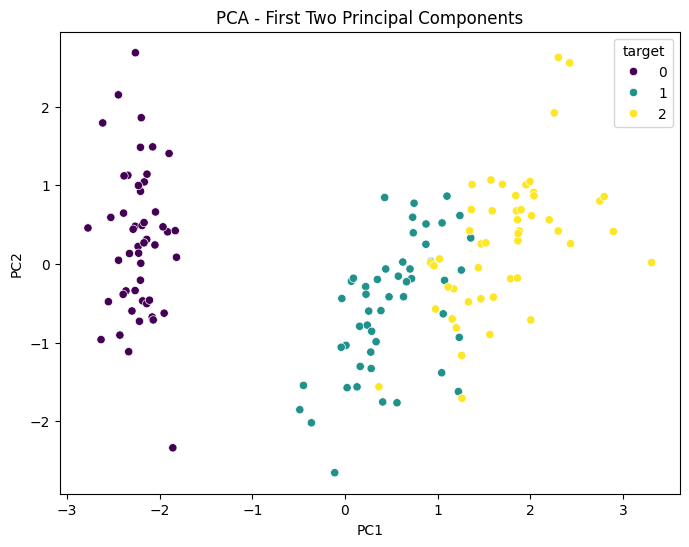

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette='viridis'
)
plt.title("PCA - First Two Principal Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


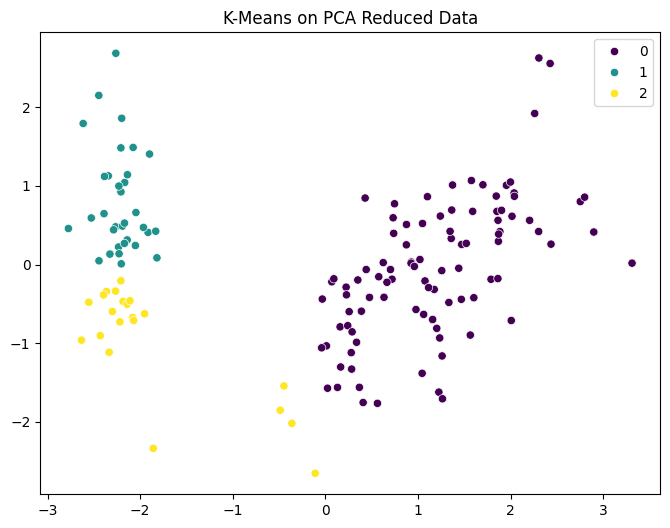

Silhouette Score (Original): 0.4798814508199818
Silhouette Score (PCA): 0.5227910941742376


In [ ]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters_pca,
    palette='viridis'
)
plt.title("K-Means on PCA Reduced Data")
plt.show()

print("Silhouette Score (Original):", silhouette_score(X_scaled, clusters))
print("Silhouette Score (PCA):", silhouette_score(X_pca, clusters_pca))


Clustering on the PCA-reduced data gives almost the same results as clustering on the original dataset with very similar silhouette scores. This shows that PCA preserves most of the important structure of the data. Therefore dimensionality reduction simplifies visualization without significantly affecting clustering performance.

# **Hierarchical Clustering**

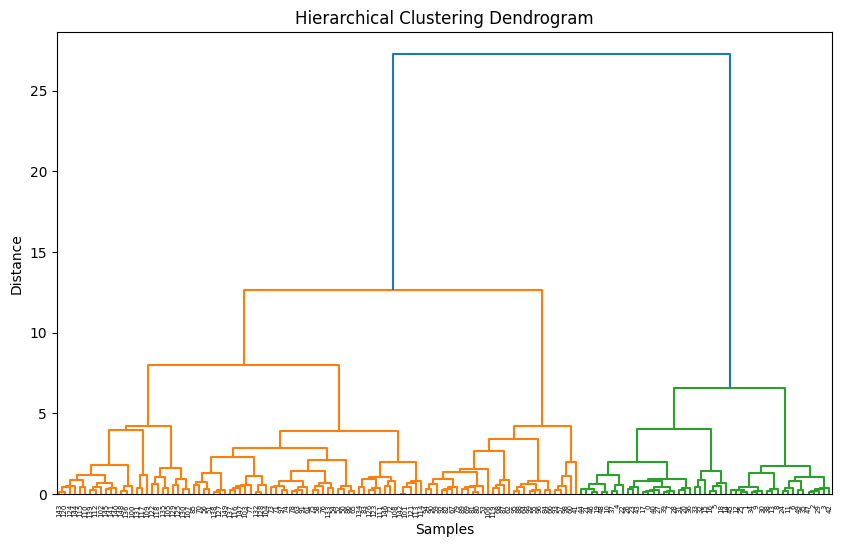

In [ ]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

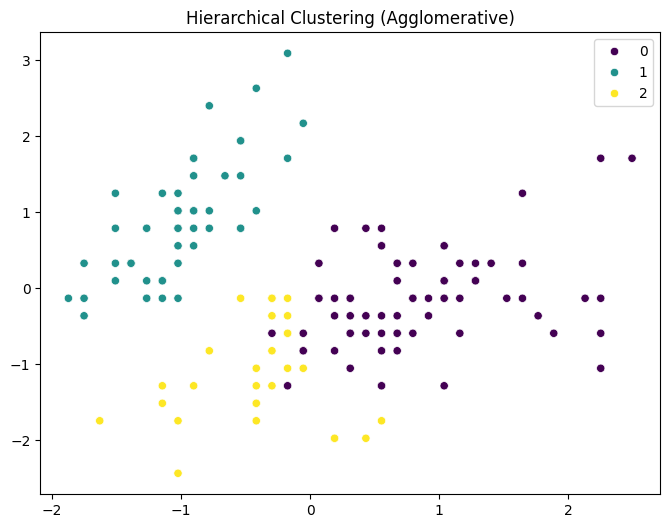

In [ ]:
hc = AgglomerativeClustering(n_clusters=3)
hc_clusters = hc.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    hue=hc_clusters,
    palette='viridis'
)
plt.title("Hierarchical Clustering (Agglomerative)")
plt.show()

Comparison with K-Means:

Results are very similar.
Hierarchical does not require pre-initialized centroids.
Slightly better structure for overlapping classes

# **DBSCAN**

In [ ]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
db_clusters = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = db_clusters

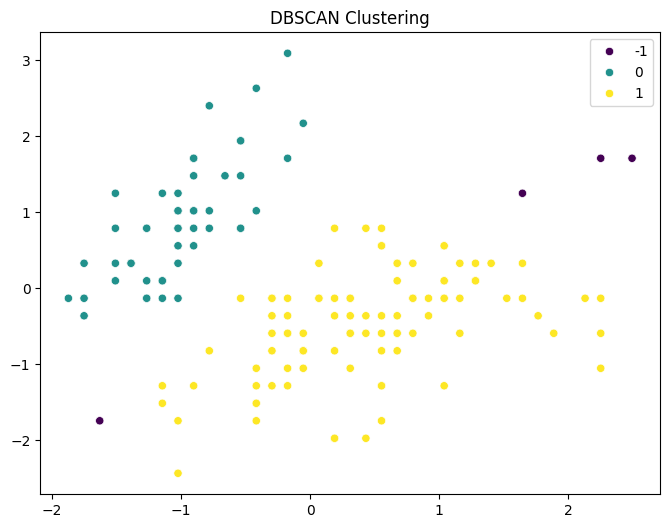

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    hue=db_clusters,
    palette='viridis'
)
plt.title("DBSCAN Clustering")
plt.show()

In [ ]:
for eps in [0.5, 0.7, 0.9]:
    for min_s in [3, 5, 7]:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_scaled)
        print(f"eps={eps}, min_samples={min_s}, clusters={set(labels)}")

eps=0.5, min_samples=3, clusters={np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(-1)}
eps=0.5, min_samples=5, clusters={np.int64(0), np.int64(1), np.int64(-1)}
eps=0.5, min_samples=7, clusters={np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(-1)}
eps=0.7, min_samples=3, clusters={np.int64(0), np.int64(1), np.int64(-1)}
eps=0.7, min_samples=5, clusters={np.int64(0), np.int64(1), np.int64(-1)}
eps=0.7, min_samples=7, clusters={np.int64(0), np.int64(1), np.int64(-1)}
eps=0.9, min_samples=3, clusters={np.int64(0), np.int64(1), np.int64(-1)}
eps=0.9, min_samples=5, clusters={np.int64(0), np.int64(1), np.int64(-1)}
eps=0.9, min_samples=7, clusters={np.int64(0), np.int64(1), np.int64(-1)}


K-Means clearly forms three clusters and separates the data better on the Iris dataset. DBSCAN can detect noise and does not require specifying the number of clusters but it performs slightly weaker here since the clusters are not strongly density-based.